# RoBERTa Polarity Training

- Train on `corpus_training_hn.csv` and `corpus_training_kaggle.csv`
- Evaluate on `corpus_evaluation.csv`

In [2]:
!pip -q install -U "transformers[torch]" datasets accelerate scikit-learn "pandas>=2.2.2,<3" matplotlib seaborn openpyxl torchview torchviz graphviz


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 97.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 129.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 120.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Import libraries

In [ ]:
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchview import draw_graph
from transformers import AutoModelForSequenceClassification
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from datasets import Dataset
from transformers import logging as transformers_logging
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding,
)

print('torch:', torch.__version__)
print('cuda available:', torch.cuda.is_available())

torch: 2.10.0+cpu
cuda available: False


## Configurations

In [7]:
TEXT_COL = 'text_transformer'
LABEL_COL = 'label_sentiment'

LABEL2ID = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
ID2LABEL = {idx: label for label, idx in LABEL2ID.items()}

BASE_DIR = Path('/content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project')
TRAIN_HN_CSV = BASE_DIR / 'data/preprocessed-data/corpus_training_hn.csv'
TRAIN_KAGGLE_CSV = BASE_DIR / 'data/preprocessed-data/corpus_training_kaggle.csv'
EVAL_CSV = BASE_DIR / 'data/preprocessed-data/corpus_evaluation.csv'
OUTPUT_DIR = BASE_DIR / 'outputs/roberta_polarity_combined'

TRAIN_MODE = 'combined'
MODEL_NAME = 'roberta-base'  # loads pretrained Facebook AI RoBERTa weights
MAX_LENGTH = 384
SEED = 42
LEARNING_RATE = 1e-5
NUM_EPOCHS = 5
EARLY_STOPPING_PATIENCE = 2
USE_WEIGHTED_LOSS = True
USE_OVERSAMPLING = False
IMBALANCE_RATIO_THRESHOLD = 1.5

## Data Preparation

- Loads training data
- Standardises labels
- Splits train and validation sets
- Optionally applies oversampling

In [32]:
cap_map = {'positive': 'Positive', 'neutral': 'Neutral', 'negative': 'Negative'}


def load_training_csv(path, text_col, label_col, source_name):
    df = pd.read_csv(path, encoding='utf-8')
    df = df[[text_col, label_col]].dropna().copy()
    df[text_col] = df[text_col].astype(str).str.strip()
    df[label_col] = df[label_col].astype(str).str.strip().replace(cap_map)
    df = df.rename(columns={text_col: TEXT_COL, label_col: LABEL_COL})
    df['source'] = source_name
    return df

if TRAIN_MODE == 'combined':
    parts = [
        load_training_csv(TRAIN_HN_CSV, TEXT_COL, LABEL_COL, 'hn'),
        load_training_csv(TRAIN_KAGGLE_CSV, TEXT_COL, LABEL_COL, 'kaggle'),
    ]
elif TRAIN_MODE == 'hn_only':
    parts = [
        load_training_csv(TRAIN_HN_CSV, TEXT_COL, LABEL_COL, 'hn'),
    ]
else:
    parts = [
        load_training_csv(TRAIN_KAGGLE_CSV, TEXT_COL, LABEL_COL, 'kaggle'),
    ]

df = pd.concat(parts, ignore_index=True)
df['labels'] = df[LABEL_COL].map(LABEL2ID)

source_counts = df['source'].value_counts()
source_ratio = source_counts.max() / source_counts.min() if len(source_counts) > 1 else 1.0
label_counts = df[LABEL_COL].value_counts().reindex(LABEL2ID.keys(), fill_value=0)

print(f'Train mode: {TRAIN_MODE}')
print(f'Total rows: {len(df)}')
print('\nSource counts:')
print(source_counts)
print(f'Source ratio: {source_ratio:.2f}')
print('\nLabel counts:')
print(label_counts)

train_df, val_df = train_test_split(
    df,
    test_size=0.1,
    random_state=SEED,
    stratify=df['labels'],
)

print(f'\nTrain rows: {len(train_df)}')
print(f'Validation rows: {len(val_df)}')

Train mode: combined
Total rows: 50899
Source counts:
source
kaggle    50000
hn          899
Name: count, dtype: int64
Source ratio: 55.62

Label counts:
label_sentiment
Negative    10157
Neutral     12953
Positive    27789
Name: count, dtype: int64

Train rows: 45809
Validation rows: 5090


## Oversampling check

In [33]:
train_label_counts = train_df[LABEL_COL].value_counts().reindex(LABEL2ID.keys(), fill_value=0)
train_non_zero = train_label_counts[train_label_counts > 0]
train_ratio = float(train_non_zero.max() / train_non_zero.min())

print(f'Train imbalance ratio before oversampling: {train_ratio:.2f}')
print('Imbalance ratio threshold:', IMBALANCE_RATIO_THRESHOLD)

Train imbalance ratio before oversampling: 2.74
Imbalance ratio threshold: 1.5


## Tokenisation

- Converts text data into tokenized Hugging Face datasets
- Computes class weights from the training split

In [34]:
def tokenize_datasets(train_df, val_df, model_name=MODEL_NAME, max_length=MAX_LENGTH):
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    def to_dataset(frame):
        ds = Dataset.from_pandas(frame[[TEXT_COL, 'labels']].reset_index(drop=True))
        ds = ds.rename_column('labels', 'label')
        return ds.map(
            lambda x: tokenizer(x[TEXT_COL], truncation=True, max_length=max_length),
            batched=True,
            remove_columns=[TEXT_COL],
        )

    train_tok = to_dataset(train_df)
    val_tok = to_dataset(val_df)
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
    return tokenizer, train_tok, val_tok, data_collator


def compute_class_weights(train_df):
    counts = train_df['labels'].value_counts().sort_index()
    num_classes = len(LABEL2ID)
    inv = (counts.sum() / (num_classes * counts)).astype(float)
    weights = np.sqrt(inv).values
    class_weights = torch.tensor(weights, dtype=torch.float)
    print('Class counts:', counts.to_dict())
    print('Class weights (Negative, Neutral, Positive):', class_weights.tolist())
    return class_weights

## Training pipeline

- The polarity pipeline uses a pretrained RoBERTa checkpoint from Hugging Face, `from_pretrained` loads the real encoder weights for robert-a.
- Training minimises cross-entropy, and when `use_weighted_loss=True`, the loss is class-weighted via the Trainer subclass (ClassWeightedTrainer) so minority polarity classes contribute more to the gradient. 
- TrainingArguments are set with `load_best_model_at_end=True` and `metric_for_best_model='f1_macro'` so after training, the Trainer reloads the checkpoint from the best validation macro-F1 epoch before the model is saved.
- EarlyStoppingCallback ends training if validation macro-F1 fails to improve for `EARLY_STOPPING_PATIENCE` consecutive evaluation rounds.

In [ ]:
class ClassWeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, use_weighted_loss=False, **kwargs):
        super().__init__(*args, **kwargs)
        self._class_weights = class_weights
        self._use_weighted_loss = use_weighted_loss

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs['labels']
        outputs = model(**{k: v for k, v in inputs.items() if k != 'labels'})
        logits = outputs['logits']

        loss = F.cross_entropy(logits, labels)
        if self._use_weighted_loss:
            loss = F.cross_entropy(logits, labels, weight=self._class_weights.to(logits.device))

        return (loss, outputs) if return_outputs else loss


def build_training_args(output_dir):
    return TrainingArguments(
        output_dir=str(output_dir),
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=NUM_EPOCHS,
        weight_decay=0.01,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='f1_macro',
        greater_is_better=True,
        logging_steps=200,
        save_total_limit=3,
        seed=SEED,
        fp16=torch.cuda.is_available(),
        report_to='none',
        max_grad_norm=1.0,
    )


def build_model(model_name=MODEL_NAME):
    return AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=len(LABEL2ID),
        id2label=ID2LABEL,
        label2id=LABEL2ID,
    )


def compute_metrics(eval_pred):
    if hasattr(eval_pred, 'predictions'):
        logits, labels = eval_pred.predictions, eval_pred.label_ids
    else:
        logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(
        labels, preds, average='macro', zero_division=0
    )
    prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
        labels, preds, average='weighted', zero_division=0
    )
    return {
        'accuracy': accuracy_score(labels, preds),
        'precision_macro': prec_m,
        'recall_macro': rec_m,
        'f1_macro': f1_m,
        'precision_weighted': prec_w,
        'recall_weighted': rec_w,
        'f1_weighted': f1_w,
    }

def build_trainer(model, tokenizer, train_tok, val_tok, data_collator, class_weights, use_weighted_loss, output_dir):
    return ClassWeightedTrainer(
        model=model,
        args=build_training_args(output_dir),
        train_dataset=train_tok,
        eval_dataset=val_tok,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        class_weights=class_weights,
        use_weighted_loss=use_weighted_loss,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
    )


def train_experiment(train_df, val_df, output_dir, use_weighted_loss, use_oversampling=False):
    tokenizer, train_tok, val_tok, data_collator = tokenize_datasets(train_df, val_df)
    class_weights = compute_class_weights(train_df)
    model = build_model()
    trainer = build_trainer(
        model,
        tokenizer,
        train_tok,
        val_tok,
        data_collator,
        class_weights,
        use_weighted_loss,
        output_dir,
    )

    print('Trainer configured with:')
    print(' - learning_rate:', LEARNING_RATE)
    print(' - num_epochs:', NUM_EPOCHS)
    print(' - max_length:', MAX_LENGTH)
    print(' - weighted_loss:', use_weighted_loss)
    print(' - oversampling:', use_oversampling)

    train_result = trainer.train()
    print(train_result)

    output_dir.mkdir(parents=True, exist_ok=True)
    trainer.save_model(output_dir / 'final_model')
    tokenizer.save_pretrained(output_dir / 'final_model')
    print(f'Saved model to {output_dir / "final_model"}')
    return {
        'trainer': trainer,
        'model': trainer.model,
        'tokenizer': tokenizer,
        'train_result': train_result,
        'train_df': train_df,
        'val_df': val_df,
        'output_dir': output_dir,
    }

## Evaluation function

In [ ]:
def evaluate_on_csv(model, tokenizer, output_dir, eval_csv=EVAL_CSV, gold_col='label_sentiment'):
    eval_raw = pd.read_csv(eval_csv, encoding='utf-8')
    eval_df = eval_raw[[TEXT_COL, gold_col]].dropna().copy()
    eval_df[TEXT_COL] = eval_df[TEXT_COL].astype(str).str.strip()
    eval_df[gold_col] = eval_df[gold_col].astype(str).str.strip().replace(cap_map)

    y_true = eval_df[gold_col].map(LABEL2ID).values
    texts = eval_df[TEXT_COL].tolist()

    model.eval()
    device = next(model.parameters()).device
    batch_size = 32
    all_logits = []

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i : i + batch_size]
            enc = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=MAX_LENGTH,
                return_tensors='pt',
            ).to(device)
            logits = model(**enc).logits.cpu().numpy()
            all_logits.append(logits)

    logits = np.vstack(all_logits)
    y_pred = logits.argmax(axis=-1)

    # Save predictions on evaluation data
    pred_export = eval_raw[[c for c in ['doc_id', 'object_id', 'text'] if c in eval_raw.columns]].copy()
    pred_export['pred_polarity'] = [ID2LABEL[i] for i in y_pred]
    pred_export_csv = output_dir / 'roberta_eval_predictions.csv'
    output_dir.mkdir(parents=True, exist_ok=True)
    pred_export.to_csv(pred_export_csv, index=False)
    print(f'Saved predictions: {pred_export_csv}')

    target_names = [ID2LABEL[i] for i in range(len(ID2LABEL))]
    labels_order = list(range(len(LABEL2ID)))

    print('\n' + '=' * 60)
    print('Evaluation on corpus_evaluation.csv')
    print('=' * 60)
    print(f'N (samples): {len(y_true)}')
    print(f'Accuracy: {accuracy_score(y_true, y_pred):.4f}' + '\n')

    prec, rec, f1, sup = precision_recall_fscore_support(
        y_true, y_pred, labels=labels_order, average=None, zero_division=0
    )
    metrics_rows = []
    for i, name in enumerate(target_names):
        metrics_rows.append(
            {'class': name, 'precision': prec[i], 'recall': rec[i], 'f1': f1[i], 'support': int(sup[i])}
        )
    metrics_df = pd.DataFrame(metrics_rows)
    for c in ('precision', 'recall', 'f1'):
        metrics_df[c] = metrics_df[c].round(4)

    eval_total_support = int(len(y_true))
    summary_rows = []
    for avg in ('macro', 'weighted'):
        p_a, r_a, f_a, _ = precision_recall_fscore_support(
            y_true, y_pred, average=avg, zero_division=0
        )
        summary_rows.append(
            {
                'average_type': avg,
                'precision': p_a,
                'recall': r_a,
                'f1': f_a,
                'support': eval_total_support,
            }
        )
    summary_df = pd.DataFrame(summary_rows)
    for c in ('precision', 'recall', 'f1'):
        summary_df[c] = summary_df[c].round(4)
    print('\nPolarity classification report:')
    print(
        classification_report(
            y_true,
            y_pred,
            labels=labels_order,
            target_names=target_names,
            digits=4,
            zero_division=0,
        )
    )

    cm = confusion_matrix(y_true, y_pred, labels=labels_order)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=target_names,
        yticklabels=target_names,
        ax=ax,
        cbar_kws={'label': 'Count'},
    )
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_title('RoBERTa Polarity Confusion Matrix')
    plt.tight_layout()
    plt.show()

    cm_path = output_dir / 'roberta_confusion_matrix_eval.png'
    output_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(cm_path, dpi=150, bbox_inches='tight')
    print(f'\nSaved figure: {cm_path}')

    part_per = metrics_df.copy()
    part_per.insert(0, 'scope', 'per_class')
    part_per = part_per.rename(columns={'class': 'name'})
    part_per = part_per[['scope', 'name', 'precision', 'recall', 'f1', 'support']]

    part_agg = summary_df.copy()
    part_agg['scope'] = part_agg['average_type']
    part_agg['name'] = part_agg['average_type']
    part_agg = part_agg.drop(columns=['average_type'])
    part_agg = part_agg[['scope', 'name', 'precision', 'recall', 'f1', 'support']]

    eval_metrics_csv = output_dir / 'roberta_eval_metrics.csv'
    pd.concat([part_per, part_agg], ignore_index=True).to_csv(eval_metrics_csv, index=False)
    print(f'Saved metrics: {eval_metrics_csv}')

    return {
        'eval_df': eval_df,
        'y_true': y_true,
        'y_pred': y_pred,
        'metrics_df': metrics_df,
        'summary_df': summary_df,
        'confusion_matrix': cm,
    }

## Run Experiments

In [ ]:
def run_experiment(
    run_name,
    output_dir=OUTPUT_DIR,
    use_weighted_loss=USE_WEIGHTED_LOSS,
    use_oversampling=USE_OVERSAMPLING,
    train_df=train_df,
    val_df=val_df,
):
    print('Running experiment:', run_name)

    if use_oversampling:
        target = train_df[LABEL_COL].value_counts().max()
        oversampled_parts = []
        for _, group in train_df.groupby(LABEL_COL, sort=False):
            oversampled_parts.append(group.sample(n=target, replace=len(group) < target, random_state=SEED))
        train_df = pd.concat(oversampled_parts, ignore_index=True).sample(frac=1.0, random_state=SEED).reset_index(drop=True)
        train_df['labels'] = train_df[LABEL_COL].map(LABEL2ID)
        print('Label counts after oversampling:')
        print(train_df[LABEL_COL].value_counts().reindex(LABEL2ID.keys(), fill_value=0))

    return train_experiment(
        train_df,
        val_df,
        output_dir=output_dir,
        use_weighted_loss=use_weighted_loss,
        use_oversampling=use_oversampling,
    )

Running experiment: roberta_polarity_baseline


Map:   0%|          | 0/45809 [00:00<?, ? examples/s]

Map:   0%|          | 0/5090 [00:00<?, ? examples/s]

Class counts: {0: 9141, 1: 11658, 2: 25010}
Class weights (Negative, Neutral, Positive): [1.2924624681472778, 1.1444655656814575, 0.7813721299171448]


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

{'loss': '4.621e-05', 'grad_norm': '0.0002446', 'learning_rate': '1.9e-06', 'epoch': '4.05'}
{'loss': '4.163e-05', 'grad_norm': '0.0001999', 'learning_rate': '1.76e-06', 'epoch': '4.12'}
{'loss': '0.00339', 'grad_norm': '0.0002866', 'learning_rate': '1.621e-06', 'epoch': '4.19'}
{'loss': '0.001355', 'grad_norm': '0.0001901', 'learning_rate': '1.481e-06', 'epoch': '4.26'}
{'loss': '0.003747', 'grad_norm': '0.0002347', 'learning_rate': '1.341e-06', 'epoch': '4.33'}
{'loss': '0.002405', 'grad_norm': '0.000182', 'learning_rate': '1.202e-06', 'epoch': '4.399'}
{'loss': '4.406e-05', 'grad_norm': '0.006686', 'learning_rate': '1.062e-06', 'epoch': '4.469'}
{'loss': '0.0001352', 'grad_norm': '0.0001852', 'learning_rate': '9.225e-07', 'epoch': '4.539'}
{'loss': '2.624e-05', 'grad_norm': '0.0001847', 'learning_rate': '7.828e-07', 'epoch': '4.609'}
{'loss': '0.0001346', 'grad_norm': '0.005075', 'learning_rate': '6.432e-07', 'epoch': '4.679'}
{'loss': '1.841e-05', 'grad_norm': '0.0002155', 'learnin

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '361.4', 'train_samples_per_second': '633.9', 'train_steps_per_second': '39.63', 'train_loss': '0.01146', 'epoch': '5'}
TrainOutput(global_step=14320, training_loss=0.01146466519014374, metrics={'train_runtime': 361.3535, 'train_samples_per_second': 633.853, 'train_steps_per_second': 39.629, 'train_loss': 0.01146466519014374, 'epoch': 5.0})


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model to /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_polarity_baseline/final_model
Saved predictions: /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_polarity_baseline/roberta_eval_predictions.csv

Evaluation on corpus_evaluation.csv
N (samples): 1000
Accuracy: 0.8460


Polarity classification report:
              precision    recall  f1-score   support

    Negative     0.8324    0.8324    0.8324       352
     Neutral     0.9363    0.7101    0.8077       207
    Positive     0.8269    0.9206    0.8712       441

    accuracy                         0.8460      1000
   macro avg     0.8652    0.8211    0.8371      1000
weighted avg     0.8515    0.8460    0.8444      1000



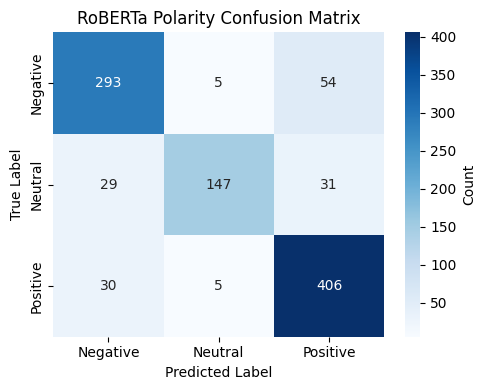


Saved figure: /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_polarity_baseline/roberta_confusion_matrix_eval.png
Saved metrics: /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_polarity_baseline/roberta_eval_metrics.csv
Running experiment: roberta_polarity_weighted_loss


Map:   0%|          | 0/45809 [00:00<?, ? examples/s]

Map:   0%|          | 0/5090 [00:00<?, ? examples/s]

Class counts: {0: 9141, 1: 11658, 2: 25010}
Class weights (Negative, Neutral, Positive): [1.2924624681472778, 1.1444655656814575, 0.7813721299171448]


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

{'loss': '4.108e-05', 'grad_norm': '0.0002685', 'learning_rate': '1.9e-06', 'epoch': '4.05'}
{'loss': '4.736e-05', 'grad_norm': '0.0002743', 'learning_rate': '1.76e-06', 'epoch': '4.12'}
{'loss': '0.002193', 'grad_norm': '0.0002797', 'learning_rate': '1.621e-06', 'epoch': '4.19'}
{'loss': '0.00218', 'grad_norm': '0.0002634', 'learning_rate': '1.481e-06', 'epoch': '4.26'}
{'loss': '0.002621', 'grad_norm': '0.0002458', 'learning_rate': '1.341e-06', 'epoch': '4.33'}
{'loss': '0.002284', 'grad_norm': '0.0002411', 'learning_rate': '1.202e-06', 'epoch': '4.399'}
{'loss': '0.001818', 'grad_norm': '0.004058', 'learning_rate': '1.062e-06', 'epoch': '4.469'}
{'loss': '0.000472', 'grad_norm': '0.0002335', 'learning_rate': '9.225e-07', 'epoch': '4.539'}
{'loss': '0.0008621', 'grad_norm': '0.0002', 'learning_rate': '7.828e-07', 'epoch': '4.609'}
{'loss': '0.0002173', 'grad_norm': '0.001635', 'learning_rate': '6.432e-07', 'epoch': '4.679'}
{'loss': '2.117e-05', 'grad_norm': '0.0002251', 'learning_ra

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '360.5', 'train_samples_per_second': '635.3', 'train_steps_per_second': '39.72', 'train_loss': '0.01258', 'epoch': '5'}
TrainOutput(global_step=14320, training_loss=0.012577582270527446, metrics={'train_runtime': 360.5185, 'train_samples_per_second': 635.321, 'train_steps_per_second': 39.721, 'train_loss': 0.012577582270527446, 'epoch': 5.0})


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model to /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_polarity_weighted_loss/final_model
Saved predictions: /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_polarity_weighted_loss/roberta_eval_predictions.csv

Evaluation on corpus_evaluation.csv
N (samples): 1000
Accuracy: 0.8700


Polarity classification report:
              precision    recall  f1-score   support

    Negative     0.8338    0.8693    0.8512       352
     Neutral     0.9432    0.8019    0.8668       207
    Positive     0.8709    0.9025    0.8864       441

    accuracy                         0.8700      1000
   macro avg     0.8826    0.8579    0.8681      1000
weighted avg     0.8728    0.8700    0.8700      1000



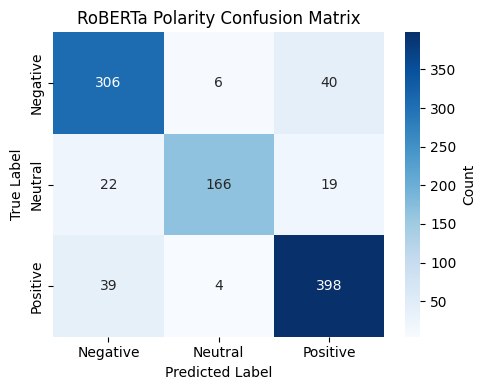


Saved figure: /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_polarity_weighted_loss/roberta_confusion_matrix_eval.png
Saved metrics: /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_polarity_weighted_loss/roberta_eval_metrics.csv
Running experiment: roberta_polarity_oversampling
Label counts after oversampling:
label_sentiment
Negative    25010
Neutral     25010
Positive    25010
Name: count, dtype: int64


Map:   0%|          | 0/75030 [00:00<?, ? examples/s]

Map:   0%|          | 0/5090 [00:00<?, ? examples/s]

Class counts: {0: 25010, 1: 25010, 2: 25010}
Class weights (Negative, Neutral, Positive): [1.0, 1.0, 1.0]


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

{'loss': '0.0008082', 'grad_norm': '0.0001805', 'learning_rate': '3.945e-06', 'epoch': '3.028'}
{'loss': '1.53e-05', 'grad_norm': '0.001537', 'learning_rate': '3.86e-06', 'epoch': '3.07'}
{'loss': '0.002543', 'grad_norm': '0.0001584', 'learning_rate': '3.774e-06', 'epoch': '3.113'}
{'loss': '4.212e-05', 'grad_norm': '0.0001852', 'learning_rate': '3.689e-06', 'epoch': '3.156'}
{'loss': '0.00686', 'grad_norm': '76.51', 'learning_rate': '3.604e-06', 'epoch': '3.198'}
{'loss': '0.002331', 'grad_norm': '0.1605', 'learning_rate': '3.519e-06', 'epoch': '3.241'}
{'loss': '0.0002062', 'grad_norm': '0.0001286', 'learning_rate': '3.433e-06', 'epoch': '3.284'}
{'loss': '1.003e-05', 'grad_norm': '0.0001376', 'learning_rate': '3.348e-06', 'epoch': '3.326'}
{'loss': '0.000219', 'grad_norm': '0.0005687', 'learning_rate': '3.263e-06', 'epoch': '3.369'}
{'loss': '0.0001666', 'grad_norm': '0.0001055', 'learning_rate': '3.177e-06', 'epoch': '3.412'}
{'loss': '3.807e-05', 'grad_norm': '0.0001149', 'learnin

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '459.3', 'train_samples_per_second': '816.8', 'train_steps_per_second': '51.06', 'train_loss': '0.01018', 'epoch': '4'}
TrainOutput(global_step=18760, training_loss=0.010177660665722059, metrics={'train_runtime': 459.2793, 'train_samples_per_second': 816.823, 'train_steps_per_second': 51.058, 'train_loss': 0.010177660665722059, 'epoch': 4.0})


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model to /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_polarity_oversampling/final_model
Saved predictions: /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_polarity_oversampling/roberta_eval_predictions.csv

Evaluation on corpus_evaluation.csv
N (samples): 1000
Accuracy: 0.8730


Polarity classification report:
              precision    recall  f1-score   support

    Negative     0.8659    0.8438    0.8547       352
     Neutral     0.8856    0.8599    0.8725       207
    Positive     0.8728    0.9025    0.8874       441

    accuracy                         0.8730      1000
   macro avg     0.8748    0.8687    0.8715      1000
weighted avg     0.8730    0.8730    0.8728      1000



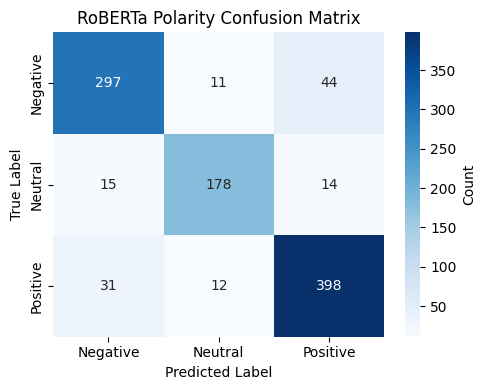


Saved figure: /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_polarity_oversampling/roberta_confusion_matrix_eval.png
Saved metrics: /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_polarity_oversampling/roberta_eval_metrics.csv
Finished runs: ['roberta_polarity_baseline', 'roberta_polarity_weighted_loss', 'roberta_polarity_oversampling']


In [38]:
experiment_setups = [
    {
        'run_name': 'roberta_polarity_baseline',
        'use_weighted_loss': False,
        'use_oversampling': False,
    },
    {
        'run_name': 'roberta_polarity_weighted_loss',
        'use_weighted_loss': True,
        'use_oversampling': False,
    },
    {
        'run_name': 'roberta_polarity_oversampling',
        'use_weighted_loss': False,
        'use_oversampling': True,
    },
]

os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
warnings.filterwarnings("ignore", category=UserWarning)
transformers_logging.set_verbosity_error()

all_run_results = {}
for setup in experiment_setups:
    run_output_dir = OUTPUT_DIR.parent / setup['run_name']
    experiment = run_experiment(
        run_name=setup['run_name'],
        output_dir=run_output_dir,
        use_weighted_loss=setup['use_weighted_loss'],
        use_oversampling=setup['use_oversampling'],
        train_df=train_df,
        val_df=val_df,
    )
    results = evaluate_on_csv(experiment['model'], experiment['tokenizer'], experiment['output_dir'])

    all_run_results[setup['run_name']] = {
        'setup': setup,
        'output_dir': run_output_dir,
        'results': results,
    }

print('Finished runs:', list(all_run_results.keys()))

## Print experiments results

In [39]:
def _get_class_row(metrics_df, class_name):
    return metrics_df[metrics_df['class'] == class_name].iloc[0]

comparison_rows = []

for run_name, payload in all_run_results.items():
    results = payload['results']
    run_output_dir = payload['output_dir']

    macro_row = results['summary_df'][results['summary_df']['average_type'] == 'macro'].iloc[0]
    weighted_row = results['summary_df'][results['summary_df']['average_type'] == 'weighted'].iloc[0]
    acc = accuracy_score(results['y_true'], results['y_pred'])

    neg_row = _get_class_row(results['metrics_df'], 'Negative')
    neu_row = _get_class_row(results['metrics_df'], 'Neutral')
    pos_row = _get_class_row(results['metrics_df'], 'Positive')

    comparison_rows.append({
        'run_name': run_name,
        'accuracy': acc,
        'macro_f1': macro_row['f1'],
        'weighted_f1': weighted_row['f1'],
        'pos_f1': pos_row['f1'],
        'neu_f1': neu_row['f1'],
        'neg_f1': neg_row['f1'],
        'pos_recall': pos_row['recall'],
        'neu_recall': neu_row['recall'],
        'neg_recall': neg_row['recall'],
        'pos_precision': pos_row['precision'],
        'neu_precision': neu_row['precision'],
        'neg_precision': neg_row['precision'],
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values('accuracy', ascending=False)
comparison_csv = OUTPUT_DIR.parent / 'roberta_experiment_comparison.csv'
comparison_df.to_csv(comparison_csv, index=False)
print('Saved comparison to:', comparison_csv)
print('\nRoBERTa Polarity Experiment Comparison')
comparison_df

Saved comparison to: /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_experiment_comparison.csv

RoBERTa Polarity Experiment Comparison


,run_name,accuracy,macro_f1,weighted_f1,pos_f1,neu_f1,neg_f1,pos_recall,neu_recall,neg_recall,pos_precision,neu_precision,neg_precision
2,roberta_polarity_oversampling,0.873,0.8715,0.8728,0.8874,0.8725,0.8547,0.9025,0.8599,0.8438,0.8728,0.8856,0.8659
1,roberta_polarity_weighted_loss,0.870,0.8681,0.8700,0.8864,0.8668,0.8512,0.9025,0.8019,0.8693,0.8709,0.9432,0.8338
0,roberta_polarity_baseline,0.846,0.8371,0.8444,0.8712,0.8077,0.8324,0.9206,0.7101,0.8324,0.8269,0.9363,0.8324


## Print model architecture

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loaded model from: /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_polarity_oversampling/final_model
Graph saved as: roberta_polarity_architecture_final


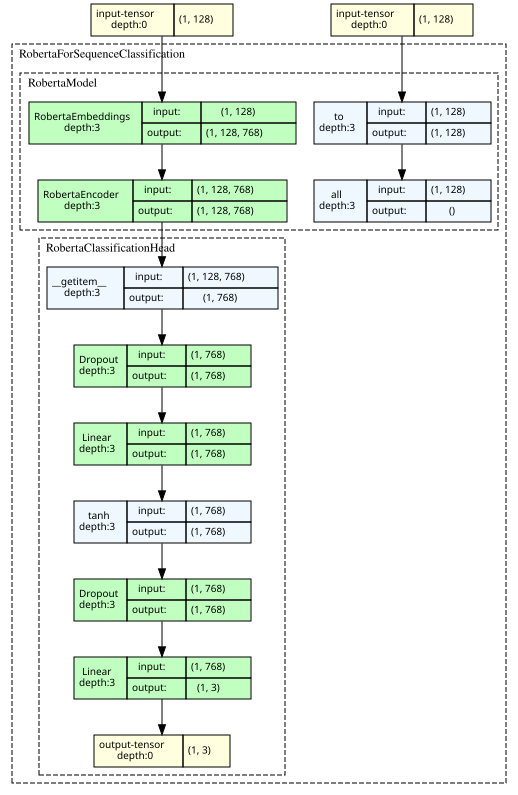

In [ ]:
if 'comparison_df' in globals() and isinstance(comparison_df, pd.DataFrame) and len(comparison_df) > 0:
    best_run_name = comparison_df.iloc[0]['run_name']
    model_dir = OUTPUT_DIR.parent / best_run_name / 'final_model'
else:
    model_dir = OUTPUT_DIR / 'final_model'

# Load model from saved checkpoint before plotting architecture
model = AutoModelForSequenceClassification.from_pretrained(model_dir)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device).eval()

class _TorchviewWrapper(nn.Module):
    def __init__(self, cls_model):
        super().__init__()
        self.roberta_model = cls_model

    def forward(self, input_ids, attention_mask):
        out = self.roberta_model(input_ids=input_ids, attention_mask=attention_mask)
        return out.logits

wrapped = _TorchviewWrapper(model).to(device).eval()
dummy_input_ids = torch.zeros((1, 128), dtype=torch.long).to(device)
dummy_mask = torch.ones((1, 128), dtype=torch.long).to(device)

graph = draw_graph(
    wrapped,
    input_data=(dummy_input_ids, dummy_mask),
    graph_name='RoBERTa_Polarity_Architecture',
    expand_nested=True,
    depth=3,
    device=device,
    hide_inner_tensors=True,
    hide_module_functions=False,
    save_graph=True,
    filename='roberta_polarity_architecture_final',
)

print('Loaded model from:', model_dir)
print('Graph saved as: roberta_polarity_architecture_final')
graph.visual_graph

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loaded model from: /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_polarity_combined/final_model
Graph artifacts directory: /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_polarity_combined/architecture_graph
Torchview graph files: roberta_polarity_architecture_final


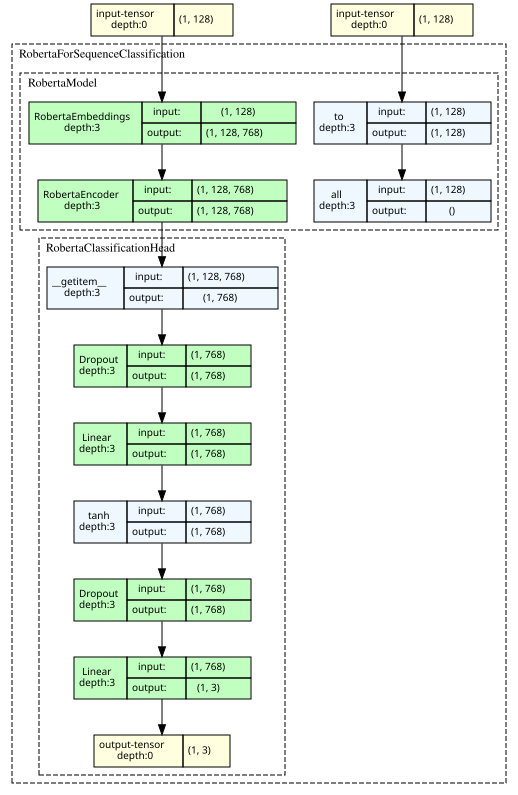

In [8]:
# Model architecture visualization (reload saved model first)

from torchview import draw_graph
import torch
import torch.nn as nn
from transformers import AutoModelForSequenceClassification

# Resolve model directory: prefer best run from comparison_df, fallback to default OUTPUT_DIR/final_model
if 'comparison_df' in globals() and isinstance(comparison_df, pd.DataFrame) and len(comparison_df) > 0:
    best_run_name = comparison_df.iloc[0]['run_name']
    model_dir = OUTPUT_DIR.parent / best_run_name / 'final_model'
else:
    model_dir = OUTPUT_DIR / 'final_model'

if not model_dir.exists():
    raise FileNotFoundError(f'Could not find saved model at: {model_dir}')

# Load model from saved checkpoint before plotting architecture
model = AutoModelForSequenceClassification.from_pretrained(model_dir)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device).eval()

class _TorchviewWrapper(nn.Module):
    def __init__(self, cls_model):
        super().__init__()
        self.roberta_model = cls_model

    def forward(self, input_ids, attention_mask):
        out = self.roberta_model(input_ids=input_ids, attention_mask=attention_mask)
        return out.logits

wrapped = _TorchviewWrapper(model).to(device).eval()

# Standard professional input shape in the diagram: (1, 128)
dummy_input_ids = torch.zeros((1, 128), dtype=torch.long).to(device)
dummy_mask = torch.ones((1, 128), dtype=torch.long).to(device)

graph_stem = 'roberta_polarity_architecture_final'
graph_save_dir = OUTPUT_DIR / 'architecture_graph'
graph_save_dir.mkdir(parents=True, exist_ok=True)

graph = draw_graph(
    wrapped,
    input_data=(dummy_input_ids, dummy_mask),
    graph_name='RoBERTa_Polarity_Architecture',
    expand_nested=True,
    depth=3,
    device=device,
    hide_inner_tensors=True,
    hide_module_functions=False,
    save_graph=True,
    filename=graph_stem,
    directory=str(graph_save_dir),
)

graph_dot_path = graph_save_dir / graph_stem
graph.visual_graph.render(filename=str(graph_dot_path), format='png', cleanup=True)

print('Loaded model from:', model_dir)
print('Graph artifacts directory:', graph_save_dir.resolve())
print('Torchview graph files:', graph_stem)
graph.visual_graph